# Previsão de Temperatura Global com Machine Learning


Neste notebook, usamos dados históricos de temperatura média global para prever valores futuros (2024, 2044 e 2069) usando um modelo de Regressão Linear.


In [46]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor, TheilSenRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures


## Carregamento dos Dados e Preparação da Série Temporal

In [47]:

df = pd.read_csv("/content/Environment_Temperature_change_E_All_Data_NOFLAG.csv", encoding="ISO-8859-1")
df.columns = df.columns.str.replace("ï»¿", "")
df = df[df["Element"] == "Temperature change"]

df_long = df.melt(id_vars=["Area", "Months", "Element", "Unit"],
                  var_name="Year", value_name="Value")
df_long["Year"] = pd.to_numeric(df_long["Year"].str.extract(r"(\d+)")[0], errors="coerce")
df_long = df_long.dropna(subset=["Year"])
df_long["Year"] = df_long["Year"].astype(int)

df_long["Value"] = pd.to_numeric(df_long["Value"], errors="coerce")
df_long.dropna(subset=["Value"], inplace=True)


/tmp/ipython-input-47-3922161556.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_long["Year"] = df_long["Year"].astype(int)
/tmp/ipython-input-47-3922161556.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_long["Value"] = pd.to_numeric(df_long["Value"], errors="coerce")
/tmp/ipython-input-47-3922161556.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/i

## Agrupar Dados Globais por Ano

In [48]:

df_global = df_long[df_long["Months"] == "Meteorological year"]
df_global = df_global.groupby("Year")["Value"].mean().reset_index()
df_global.head()


,Year,Value
0,1961,0.170922
1,1962,-0.022873
2,1963,-0.028361
3,1964,-0.106037
4,1965,-0.254930


## Treinamento do Modelo

In [49]:
# Features e alvo
X = df_global[["Year"]]
y = df_global["Value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelos a testar
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "Polynomial (deg=2)": make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    "Huber": HuberRegressor(),
    "TheilSen": TheilSenRegressor()
}

# Treinar e avaliar os modelos
print("Resultados de RMSE:")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = sqrt(mean_squared_error(y_test, preds))
    print(f"{name}: RMSE = {rmse:.4f}")


Resultados de RMSE:
LinearRegression: RMSE = 0.2123
Ridge: RMSE = 0.2123
Lasso: RMSE = 0.2089
ElasticNet: RMSE = 0.2105
Polynomial (deg=2): RMSE = 0.1580
Huber: RMSE = 0.2126
TheilSen: RMSE = 0.2717


## Previsões Futuras para 2024, 2044 e 2069

In [50]:
best_model = models["Polynomial (deg=2)"]

anos_futuros = pd.DataFrame({"Year": [2024, 2034, 2044, 2059, 2069, 2100]})
previsoes = best_model.predict(anos_futuros)

for ano, temp in zip(anos_futuros["Year"], previsoes):
    print(f"Previsão para {ano}: {temp:.2f} °C")


Previsão para 2024: 1.63 °C
Previsão para 2034: 2.13 °C
Previsão para 2044: 2.69 °C
Previsão para 2059: 3.64 °C
Previsão para 2069: 4.34 °C
Previsão para 2100: 6.90 °C


## Visualização da Tendência e Previsões

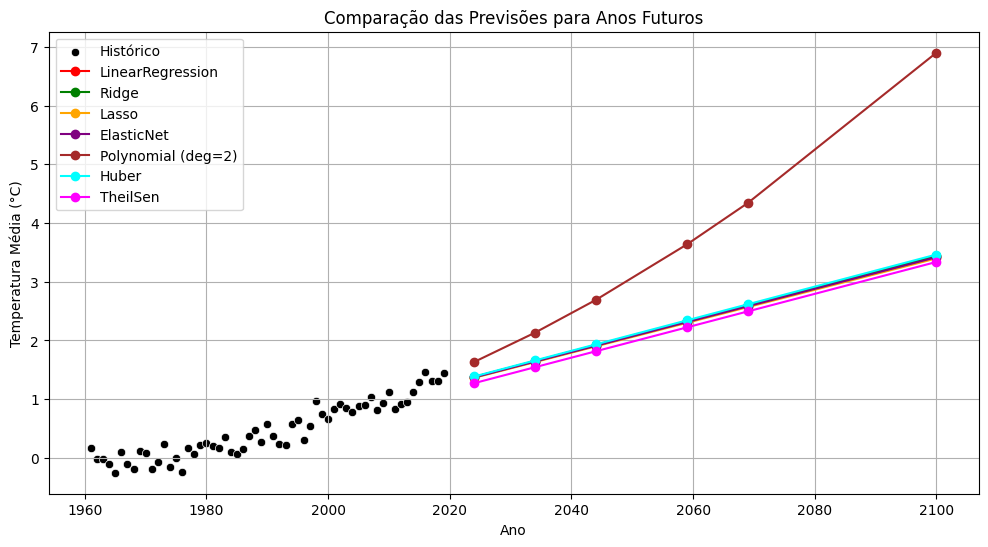

In [51]:
anos_futuros = pd.DataFrame({"Year": [2024, 2034, 2044, 2059, 2069, 2100]})

plt.figure(figsize=(12, 6))
sns.scatterplot(x="Year", y="Value", data=df_global, label="Histórico", color='black')

cores = ['red', 'green', 'orange', 'purple', 'brown', 'cyan', 'magenta']
for (name, model), cor in zip(models.items(), cores):
    preds_futuros = model.predict(anos_futuros)
    plt.plot(anos_futuros["Year"], preds_futuros, label=name, color=cor, marker='o')

plt.title("Comparação das Previsões para Anos Futuros")
plt.xlabel("Ano")
plt.ylabel("Temperatura Média (°C)")
plt.legend()
plt.grid(True)
plt.show()


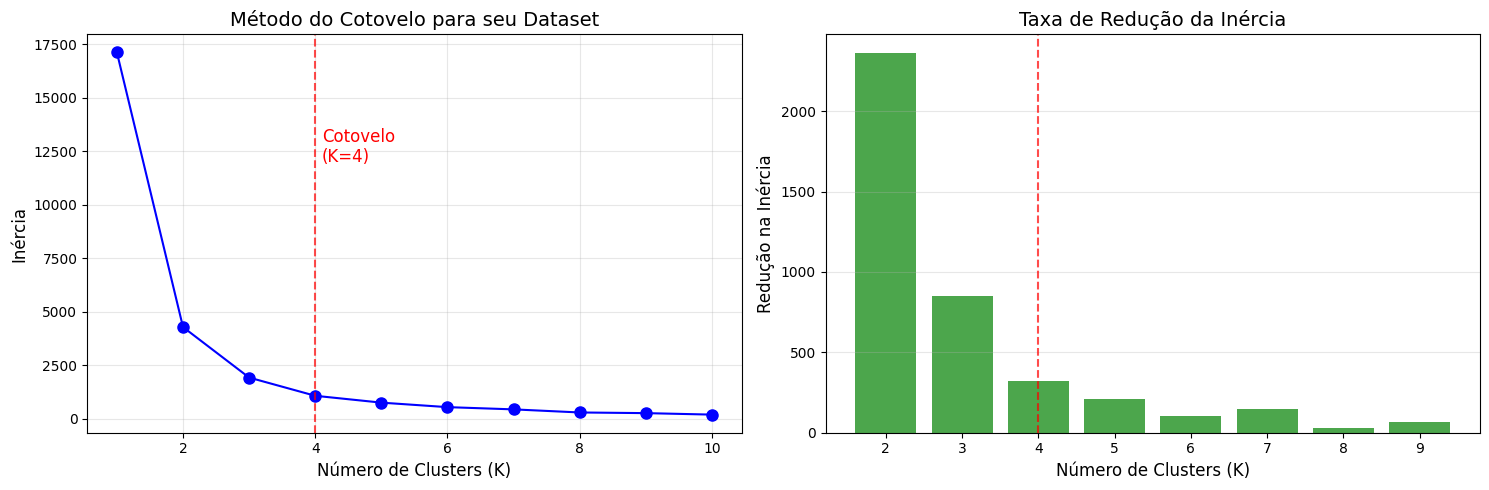

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Dados para clustering
X = df_global[["Year", "Value"]].values

inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Calcula a taxa de mudança (segunda derivada aproximada)
deltas = np.diff(inertias)
deltas2 = np.diff(deltas)

# Plotagem
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico do método do cotovelo
ax1.plot(K_range, inertias, 'bo-', markersize=8)
# Tentativa automática para achar o cotovelo aproximado (pode ajustar manualmente)
cotovelo = 4
ax1.axvline(x=cotovelo, color='red', linestyle='--', alpha=0.7)
ax1.set_xlabel('Número de Clusters (K)', fontsize=12)
ax1.set_ylabel('Inércia', fontsize=12)
ax1.set_title('Método do Cotovelo para seu Dataset', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.text(cotovelo + 0.1, max(inertias)*0.7, f'Cotovelo\n(K={cotovelo})', fontsize=12, color='red')

# Gráfico da taxa de redução da inércia
ax2.bar(range(2, 10), -deltas[1:], alpha=0.7, color='green')
ax2.set_xlabel('Número de Clusters (K)', fontsize=12)
ax2.set_ylabel('Redução na Inércia', fontsize=12)
ax2.set_title('Taxa de Redução da Inércia', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')
ax2.axvline(x=cotovelo, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



## Clustering KMenas


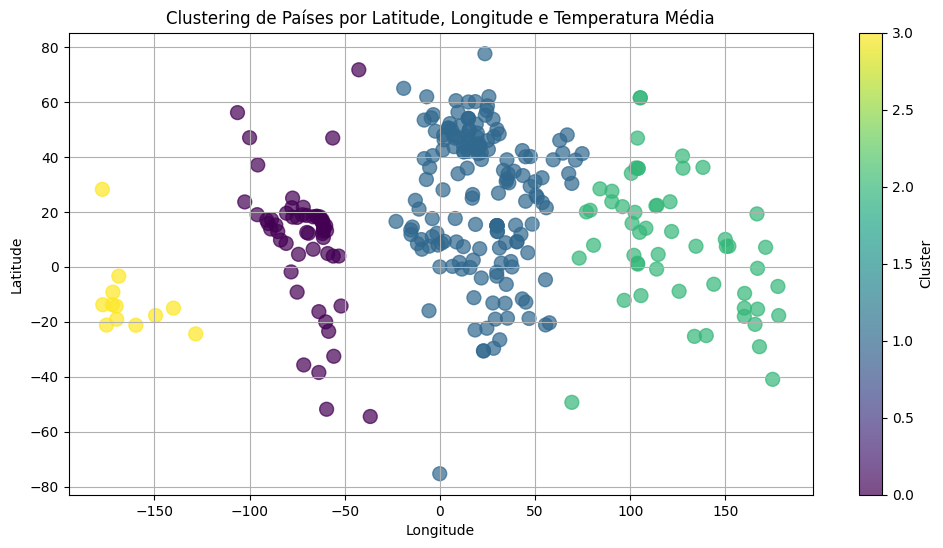

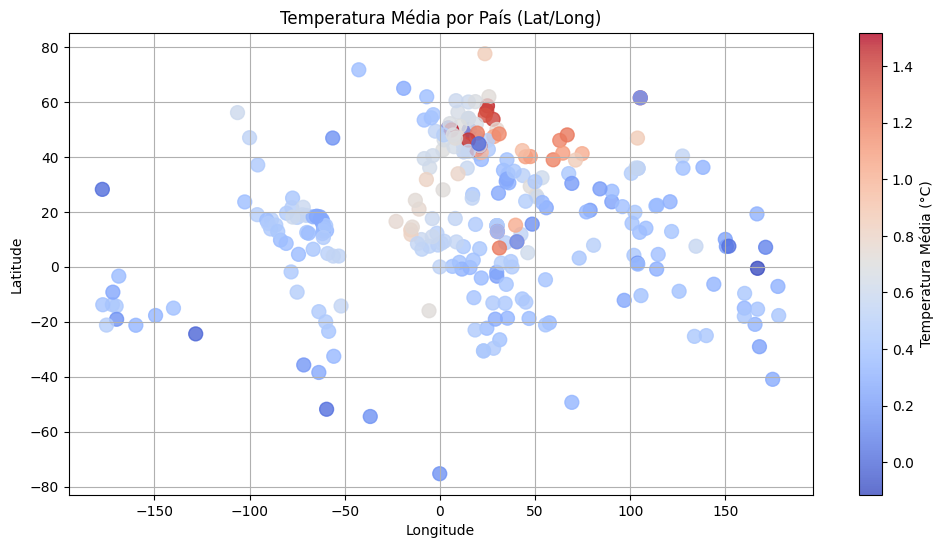

In [53]:

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Lista de países com coordenadas
country_coords = {
    "Afghanistan": (33.93911, 67.70995),
    "Albania": (41.15333, 20.16833),
    "Algeria": (28.03389, 1.65963),
    "American Samoa": (-14.27097, -170.13222),
    "Andorra": (42.50632, 1.52184),
    "Angola": (-11.20269, 17.87389),
    "Anguilla": (18.22055, -63.06861),
    "Antarctica": (-75.25097, -0.07139),
    "Antigua and Barbuda": (17.06082, -61.79643),
    "Argentina": (-38.41610, -63.61667),
    "Aruba": (12.52111, -69.96834),
    "Australia": (-25.27440, 133.77514),
    "Austria": (47.51623, 14.55007),
    "Bahamas": (25.03428, -77.39628),
    "Bahrain": (26.06670, 50.55770),
    "Bangladesh": (23.68500, 90.35633),
    "Barbados": (13.19389, -59.54320),
    "Belgium-Luxembourg": (50.50389, 4.46994),
    "Belize": (17.18988, -88.49765),
    "Benin": (9.30769, 2.31583),
    "Bhutan": (27.51416, 90.43360),
    "Bolivia (Plurinational State of)": (-16.29015, -63.58865),
    "Botswana": (-22.32847, 24.68487),
    "Brazil": (-14.23500, -51.92528),
    "British Virgin Islands": (18.42069, -64.63997),
    "Brunei Darussalam": (4.53528, 114.72767),
    "Bulgaria": (42.73388, 25.48583),
    "Burkina Faso": (12.23833, -1.56159),
    "Burundi": (-3.37306, 29.91889),
    "Cabo Verde": (16.53880, -23.04180),
    "Cambodia": (12.56568, 104.99096),
    "Cameroon": (7.36972, 12.35472),
    "Canada": (56.13037, -106.34677),
    "Cayman Islands": (19.51347, -80.56696),
    "Central African Republic": (6.61111, 20.93944),
    "Chad": (15.45417, 18.73221),
    "Channel Islands": (49.37228, -2.36435),
    "Chile": (-35.67515, -71.54297),
    "China": (35.86166, 104.19540),
    "China, Hong Kong SAR": (22.39643, 114.10950),
    "China, Macao SAR": (22.19875, 113.54387),
    "China, mainland": (35.86166, 104.19540),
    "China, Taiwan Province of": (23.69781, 120.96052),
    "Cocos (Keeling) Islands": (-12.16417, 96.87096),
    "Colombia": (4.57087, -74.29733),
    "Comoros": (-11.64550, 43.33330),
    "Congo": (-0.22802, 15.82766),
    "Cook Islands": (-21.23674, -159.77766),
    "Côte d'Ivoire": (7.53999, -5.54708),
    "Cuba": (21.52176, -77.78117),
    "Cyprus": (35.12641, 33.42986),
    "Czechoslovakia": (49.81749, 15.47296),
    "Democratic People's Republic of Korea": (40.33985, 127.51009),
    "Democratic Republic of the Congo": (-4.03833, 21.75866),
    "Denmark": (56.26392, 9.50179),
    "Djibouti": (11.82514, 42.59028),
    "Dominica": (15.41499, -61.37098),
    "Dominican Republic": (18.73569, -70.16265),
    "Ecuador": (-1.83124, -78.18341),
    "Egypt": (26.82055, 30.80250),
    "El Salvador": (13.79419, -88.89653),
    "Equatorial Guinea": (1.65080, 10.26790),
    "Eswatini": (-26.52250, 31.46590),
    "Ethiopia PDR": (9.14500, 40.48967),
    "Falkland Islands (Malvinas)": (-51.79625, -59.52361),
    "Faroe Islands": (61.89264, -6.91181),
    "Fiji": (-17.71337, 178.06503),
    "Finland": (61.92411, 25.74815),
    "France": (46.22764, 2.21375),
    "French Guiana": (3.93389, -53.12578),
    "French Polynesia": (-17.67974, -149.40684),
    "French Southern and Antarctic Territories": (-49.28037, 69.34856),
    "Gabon": (-0.80369, 11.60944),
    "Gambia": (13.44318, -15.31014),
    "Germany": (51.16569, 10.45153),
    "Ghana": (7.94653, -1.02319),
    "Gibraltar": (36.14075, -5.35359),
    "Greece": (39.07421, 21.82431),
    "Greenland": (71.70694, -42.60430),
    "Grenada": (12.11653, -61.67899),
    "Guadeloupe": (16.26500, -61.55099),
    "Guatemala": (15.78347, -90.23076),
    "Guinea": (9.94559, -9.69665),
    "Guinea-Bissau": (11.80375, -15.18041),
    "Guyana": (4.86042, -58.93018),
    "Haiti": (18.97119, -72.28522),
    "Holy See": (41.90292, 12.45339),
    "Honduras": (15.19999, -86.24190),
    "Hungary": (47.16249, 19.50330),
    "Iceland": (64.96305, -19.02084),
    "India": (20.59368, 78.96288),
    "Indonesia": (-0.78928, 113.92133),
    "Iran (Islamic Republic of)": (32.42791, 53.68805),
    "Iraq": (33.22319, 43.67929),
    "Ireland": (53.41291, -8.24389),
    "Isle of Man": (54.23611, -4.54806),
    "Israel": (31.04605, 34.85161),
    "Italy": (41.87194, 12.56738),
    "Jamaica": (18.10958, -77.29751),
    "Japan": (36.20482, 138.25292),
    "Jordan": (30.58516, 36.23841),
    "Kenya": (-0.02356, 37.90619),
    "Kiribati": (-3.37042, -168.73404),
    "Kuwait": (29.31166, 47.48177),
    "Lao People's Democratic Republic": (19.85627, 102.49550),
    "Lebanon": (33.85472, 35.86229),
    "Lesotho": (-29.60999, 28.23361),
    "Liberia": (6.42806, -9.42950),
    "Libya": (26.33510, 17.22833),
    "Liechtenstein": (47.16600, 9.55537),
    "Madagascar": (-18.76695, 46.86911),
    "Malawi": (-13.25431, 34.30153),
    "Malaysia": (4.21048, 101.97577),
    "Mali": (17.57069, -3.99617),
    "Malta": (35.93750, 14.37542),
    "Martinique": (14.64153, -61.02417),
    "Mauritania": (21.00789, -10.94083),
    "Mauritius": (-20.34840, 57.55215),
    "Mayotte": (-12.82750, 45.16624),
    "Mexico": (23.63450, -102.55278),
    "Midway Island": (28.20722, -177.38028),
    "Monaco": (43.73842, 7.42462),
    "Mongolia": (46.86250, 103.84666),
    "Montserrat": (16.74250, -62.18737),
    "Morocco": (31.79170, -7.09262),
    "Mozambique": (-18.66570, 35.52956),
    "Myanmar": (21.91622, 95.95597),
    "Namibia": (-22.95764, 18.49041),
    "Nauru": (-0.52278, 166.93150),
    "Nepal": (28.39486, 84.12401),
    "Netherlands": (52.13263, 5.29127),
    "Netherlands Antilles (former)": (12.22608, -69.06009),
    "New Caledonia": (-20.90431, 165.61804),
    "New Zealand": (-40.90056, 174.88597),
    "Nicaragua": (12.86542, -85.20723),
    "Niger": (17.60779, 8.08167),
    "Nigeria": (9.08199, 8.67528),
    "Niue": (-19.05445, -169.86723),
    "Norfolk Island": (-29.04084, 167.95471),
    "Norway": (60.47202, 8.46895),
    "Oman": (21.51258, 55.92326),
    "Pacific Islands Trust Territory": (7.51498, 151.86491),
    "Pakistan": (30.37532, 69.34512),
    "Palestine": (31.95216, 35.23315),
    "Papua New Guinea": (-6.31499, 143.95555),
    "Paraguay": (-23.44250, -58.44383),
    "Peru": (-9.18997, -75.01515),
    "Philippines": (12.87972, 121.77402),
    "Pitcairn Islands": (-24.37674, -128.32424),
    "Poland": (51.91944, 19.14514),
    "Portugal": (39.39987, -8.22445),
    "Puerto Rico": (18.22083, -66.59015),
    "Qatar": (25.35483, 51.18388),
    "Republic of Korea": (35.90776, 127.76692),
    "Réunion": (-21.11514, 55.53638),
    "Romania": (45.94316, 24.96676),
    "Rwanda": (-1.94028, 29.87389),
    "Saint Helena, Ascension and Tristan da Cunha": (-15.96501, -5.70892),
    "Saint Kitts and Nevis": (17.35782, -62.78299),
    "Saint Lucia": (13.90944, -60.97889),
    "Saint Pierre and Miquelon": (46.88520, -56.31590),
    "Saint Vincent and the Grenadines": (12.98430, -61.28723),
    "Samoa": (-13.75903, -172.10463),
    "San Marino": (43.94236, 12.45778),
    "Sao Tome and Principe": (0.18636, 6.61308),
    "Saudi Arabia": (23.88594, 45.07916),
    "Senegal": (14.49740, -14.45236),
    "Seychelles": (-4.67957, 55.49198),
    "Sierra Leone": (8.46056, -11.77989),
    "Singapore": (1.35208, 103.81984),
    "Solomon Islands": (-9.64571, 160.15619),
    "Somalia": (5.15215, 46.19962),
    "South Africa": (-30.55948, 22.93751),
    "South Georgia and the South Sandwich Islands": (-54.42958, -36.58791),
    "Spain": (40.46367, -3.74922),
    "Sri Lanka": (7.87305, 80.77180),
    "Sudan (former)": (12.86281, 30.21764),
    "Suriname": (3.91930, -56.02778),
    "Svalbard and Jan Mayen Islands": (77.55360, 23.67027),
    "Sweden": (60.12816, 18.64350),
    "Switzerland": (46.81819, 8.22751),
    "Syrian Arab Republic": (34.80208, 38.99681),
    "Thailand": (15.87003, 100.99254),
    "Timor-Leste": (-8.87422, 125.72754),
    "Togo": (8.61954, 0.82478),
    "Tokelau": (-9.20016, -171.84834),
    "Tonga": (-21.17899, -175.19824),
    "Trinidad and Tobago": (10.69180, -61.22250),
    "Tunisia": (33.88692, 9.53750),
    "Turkey": (38.96375, 35.24332),
    "Turks and Caicos Islands": (21.69403, -71.79793),
    "Tuvalu": (-7.10954, 177.64933),
    "Uganda": (1.37333, 32.29028),
    "United Arab Emirates": (23.42408, 53.84782),
    "United Kingdom": (55.37805, -3.43597),
    "United Republic of Tanzania": (-6.36903, 34.88882),
    "United States of America": (37.09024, -95.71289),
    "United States Virgin Islands": (18.33576, -64.89634),
    "Uruguay": (-32.52278, -55.76583),
    "USSR": (61.52401, 105.31876),
    "Vanuatu": (-15.37671, 166.95916),
    "Venezuela (Bolivarian Republic of)": (6.42375, -66.58973),
    "Viet Nam": (14.05832, 108.27720),
    "Wallis and Futuna Islands": (-13.76875, -177.15610),
    "Western Sahara": (24.21553, -12.88583),
    "Yemen": (15.55273, 48.51639),
    "Yugoslav SFR": (44.80401, 20.46513),
    "Zambia": (-13.13390, 27.84933),
    "Zimbabwe": (-19.01544, 29.15486),
    "World": (0.00000, 0.00000),
    "Africa": (8.78320, 34.50850),
    "Eastern Africa": (1.95770, 37.29720),
    "Middle Africa": (2.46000, 17.54000),
    "Northern Africa": (25.00000, 17.00000),
    "Southern Africa": (-30.55950, 22.93750),
    "Western Africa": (11.00000, -4.00000),
    "Americas": (19.00000, -96.00000),
    "Northern America": (47.00000, -100.00000),
    "Central America": (17.00000, -91.00000),
    "Caribbean": (18.00000, -75.00000),
    "South America": (-20.00000, -60.00000),
    "Asia": (34.04790, 100.61970),
    "Eastern Asia": (36.00000, 103.00000),
    "Southern Asia": (20.00000, 77.00000),
    "South-Eastern Asia": (1.00000, 104.00000),
    "Western Asia": (31.00000, 50.00000),
    "Europe": (54.00000, 15.00000),
    "Eastern Europe": (50.00000, 30.00000),
    "Northern Europe": (60.00000, 15.00000),
    "Southern Europe": (42.00000, 15.00000),
    "Western Europe": (48.00000, 7.00000),
    "Oceania": (-18.00000, 160.00000),
    "Australia and New Zealand": (-25.00000, 140.00000),
    "Melanesia": (-15.00000, 160.00000),
    "Micronesia": (10.00000, 150.00000),
    "Polynesia": (-15.00000, -140.00000),
    "European Union": (54.00000, 15.00000),
    "Least Developed Countries": (15.00000, 30.00000),
    "Land Locked Developing Countries": (15.00000, 30.00000),
    "Small Island Developing States": (15.00000, -60.00000),
    "Low Income Food Deficit Countries": (15.00000, 30.00000),
    "Net Food Importing Developing Countries": (15.00000, 30.00000),
    "Annex I countries": (54.00000, 15.00000),
    "Non-Annex I countries": (15.00000, 30.00000),
    "OECD": (48.00000, 2.00000),
    "Maldives": (3.20278, 73.22068),
    "Panama": (8.53798, -80.78213),
    "Costa Rica": (9.74892, -83.75343),
    "Christmas Island": (-10.44753, 105.69045),
    "Wake Island": (19.28232, 166.64705),
    "Marshall Islands": (7.13147, 171.18448),
    "Micronesia (Federated States of)": (7.42555, 150.55081),
    "Palau": (7.51498, 134.58252),
    "Armenia": (40.06910, 45.03819),
    "Azerbaijan": (40.14310, 47.57693),
    "Belarus": (53.70981, 27.95339),
    "Bosnia and Herzegovina": (43.91589, 17.67908),
    "Croatia": (45.10000, 15.20000),
    "Estonia": (58.59527, 25.01361),
    "Georgia": (42.31541, 43.35689),
    "Kazakhstan": (48.01957, 66.92368),
    "Kyrgyzstan": (41.20438, 74.76610),
    "Latvia": (56.87964, 24.60319),
    "Lithuania": (55.16944, 23.88127),
    "North Macedonia": (41.60863, 21.74528),
    "Republic of Moldova": (47.41163, 28.36989),
    "Russian Federation": (61.52401, 105.31876),
    "Serbia and Montenegro": (44.01652, 21.00586),
    "Slovenia": (46.15124, 14.99546),
    "Tajikistan": (38.86103, 71.27609),
    "Turkmenistan": (38.96972, 59.55628),
    "Ukraine": (48.37943, 31.16558),
    "Uzbekistan": (41.37749, 64.58526),
    "Central Asia": (46.00000, 63.00000),
    "Czechia": (49.81749, 15.47296),
    "Eritrea": (15.17938, 39.78233),
    "Ethiopia": (9.14500, 40.48967),
    "Slovakia": (48.66903, 19.69902),
    "Belgium": (50.50389, 4.46994),
    "Luxembourg": (49.81527, 6.12958),
    "Montenegro": (42.70868, 19.37439),
    "Serbia": (44.01652, 21.00586),
    "South Sudan": (6.87699, 31.30698),
    "Sudan": (12.86281, 30.21764)
}

# Adicionando latitude e longitude ao df_long
df_long["Latitude"] = df_long["Area"].map(lambda x: country_coords.get(x, (None, None))[0])
df_long["Longitude"] = df_long["Area"].map(lambda x: country_coords.get(x, (None, None))[1])

# Remover linhas com coordenadas ausentes
df_cluster = df_long.dropna(subset=["Latitude", "Longitude", "Value"])

# Clustering
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = df_cluster[["Latitude", "Longitude", "Value"]]
kmeans = KMeans(n_clusters=4, random_state=42)
df_cluster["Cluster"] = kmeans.fit_predict(X)

# Calcular temperatura média por país
df_avg_temp = df_long.groupby("Area")["Value"].mean().reset_index()
df_avg_temp.rename(columns={"Value": "AvgTemperature"}, inplace=True)

# Obter Latitude e Longitude únicas por país
df_coords = df_long[["Area", "Latitude", "Longitude"]].drop_duplicates(subset="Area")

# Unir temperatura média com coordenadas
df_cluster = pd.merge(df_avg_temp, df_coords, on="Area")

# Remover linhas com dados ausentes
df_cluster = df_cluster.dropna(subset=["Latitude", "Longitude", "AvgTemperature"])

# Clustering com KMeans
from sklearn.cluster import KMeans

X = df_cluster[["Latitude", "Longitude", "AvgTemperature"]]
kmeans = KMeans(n_clusters=4, random_state=42)
df_cluster["Cluster"] = kmeans.fit_predict(X)

# Plot dos clusters
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
scatter = plt.scatter(df_cluster["Longitude"], df_cluster["Latitude"],
                      c=df_cluster["Cluster"], cmap="viridis", s=100, alpha=0.7)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Clustering de Países por Latitude, Longitude e Temperatura Média")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
scatter = plt.scatter(
    df_cluster["Longitude"],
    df_cluster["Latitude"],
    c=df_cluster["AvgTemperature"],
    cmap="coolwarm",  # ou 'plasma', 'inferno', etc
    s=100,
    alpha=0.8
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Temperatura Média por País (Lat/Long)")
cbar = plt.colorbar(scatter)
cbar.set_label("Temperatura Média (°C)")
plt.grid(True)
plt.show()


## Previsão por Áreas

In [54]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

anos_futuros = np.array([2024, 2034, 2044, 2059, 2069, 2100]).reshape(-1, 1)

# Lista para armazenar resultados
lista_resultados = []

# Lista de todas as áreas únicas
areas = df_long["Area"].unique()

for area in areas:
    df_area = df_long[(df_long["Area"] == area) & (df_long["Months"] == "Meteorological year")].dropna(subset=["Value"])

    # Precisa ter dados suficientes para treinar
    if len(df_area) < 10:
        continue  # pula áreas com poucos dados

    X = df_area[["Year"]]
    y = df_area["Value"]

    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)
    model = LinearRegression()
    model.fit(X_poly, y)

    # Previsão para os anos futuros
    X_futuro_poly = poly.transform(anos_futuros)
    preds_futuro = model.predict(X_futuro_poly)

    # Guardar resultados
    for ano, pred in zip(anos_futuros.flatten(), preds_futuro):
        lista_resultados.append({"Area": area, "Year": ano, "Predicted_Temperature": pred})

# Criar DataFrame com previsões
df_previsoes = pd.DataFrame(lista_resultados)

print(df_previsoes.head())

# Opcional: salvar para CSV
# df_previsoes.to_csv("previsoes_temperatura_areas.csv", index=False)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist

          Area  Year  Predicted_Temperature
0  Afghanistan  2024               1.599635
1  Afghanistan  2034               2.114254
2  Afghanistan  2044               2.694090
3  Afghanistan  2059               3.686127
4  Afghanistan  2069               4.429007


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


/tmp/ipython-input-55-730683284.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x="Predicted_Temperature", y="Area", palette="magma")


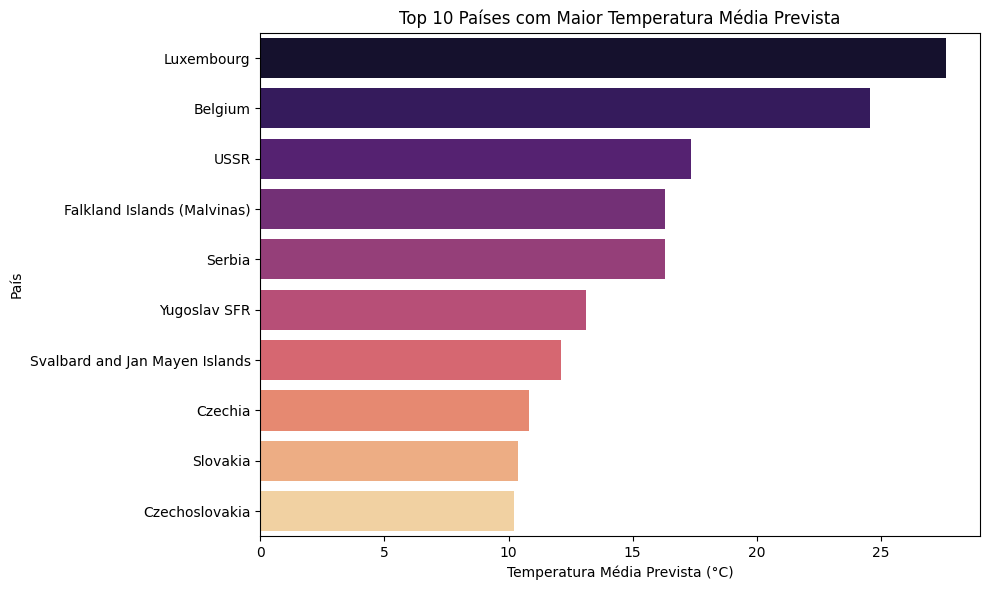

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar por Área e calcular média da temperatura prevista
media_por_area = df_previsoes.groupby("Area")["Predicted_Temperature"].mean().reset_index()

# Ordenar do maior para o menor
media_por_area = media_por_area.sort_values(by="Predicted_Temperature", ascending=False)

# Selecionar os 10 maiores
top_10 = media_por_area.head(10)

# Plotar gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10, x="Predicted_Temperature", y="Area", palette="magma")

plt.title("Top 10 Países com Maior Temperatura Média Prevista")
plt.xlabel("Temperatura Média Prevista (°C)")
plt.ylabel("País")
plt.tight_layout()
plt.show()


/tmp/ipython-input-56-2888630163.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_10, x="Predicted_Temperature", y="Area", palette="coolwarm")


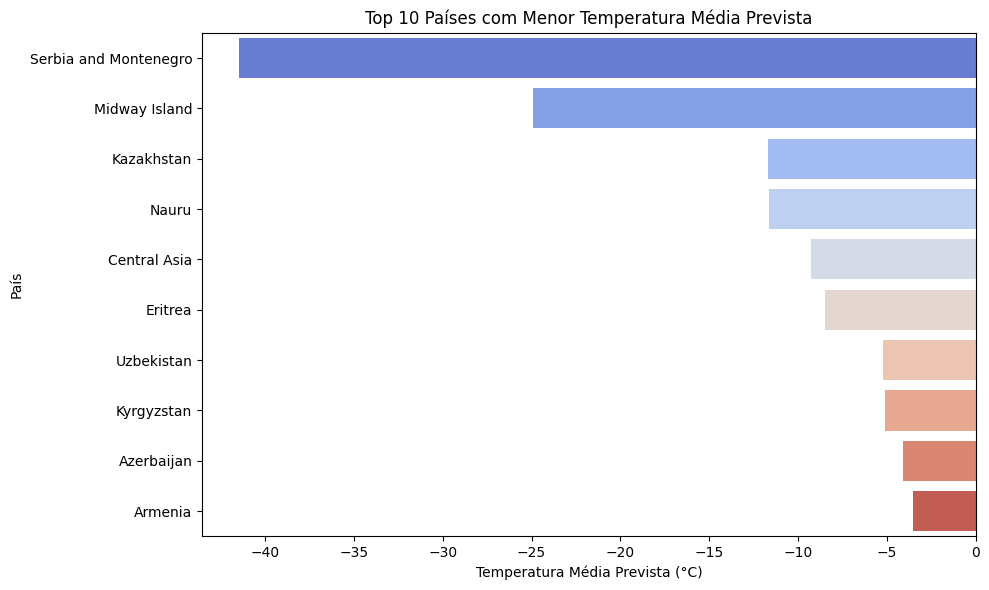

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar por Área e calcular média da temperatura prevista
media_por_area = df_previsoes.groupby("Area")["Predicted_Temperature"].mean().reset_index()

# Ordenar do menor para o maior
media_por_area = media_por_area.sort_values(by="Predicted_Temperature", ascending=True)

# Selecionar os 10 menores
bottom_10 = media_por_area.head(10)

# Plotar gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(data=bottom_10, x="Predicted_Temperature", y="Area", palette="coolwarm")

plt.title("Top 10 Países com Menor Temperatura Média Prevista")
plt.xlabel("Temperatura Média Prevista (°C)")
plt.ylabel("País")
plt.tight_layout()
plt.show()
